In [3]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

C:\Users\PRABHAV\AppData\Local\Temp\ipykernel_13864\694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [7]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

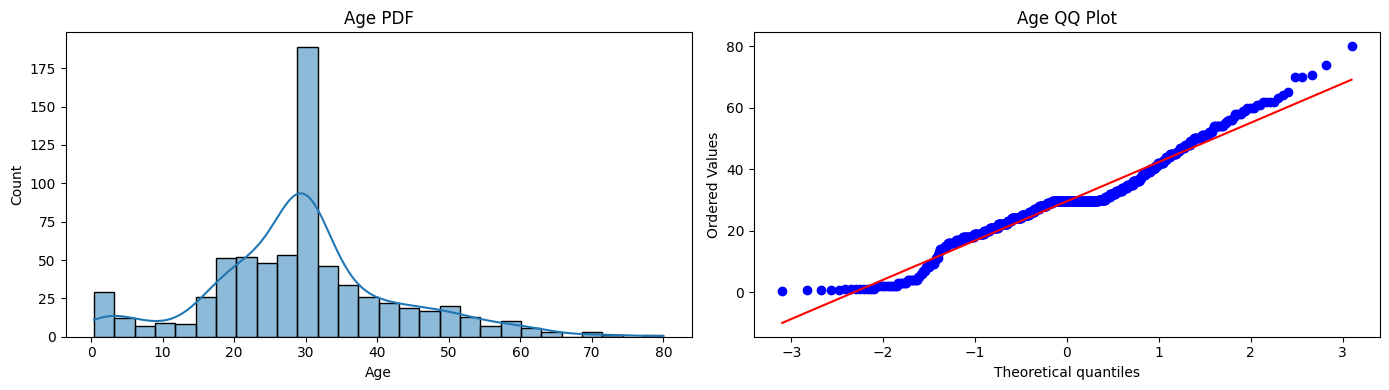

In [17]:
plt.close('all')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))


sns.histplot(X_train['Age'], kde=True, ax=ax[0])
ax[0].set_title('Age PDF')

stats.probplot(X_train['Age'], dist='norm', plot=ax[1])
ax[1].set_title('Age QQ Plot')

plt.tight_layout()
plt.show()

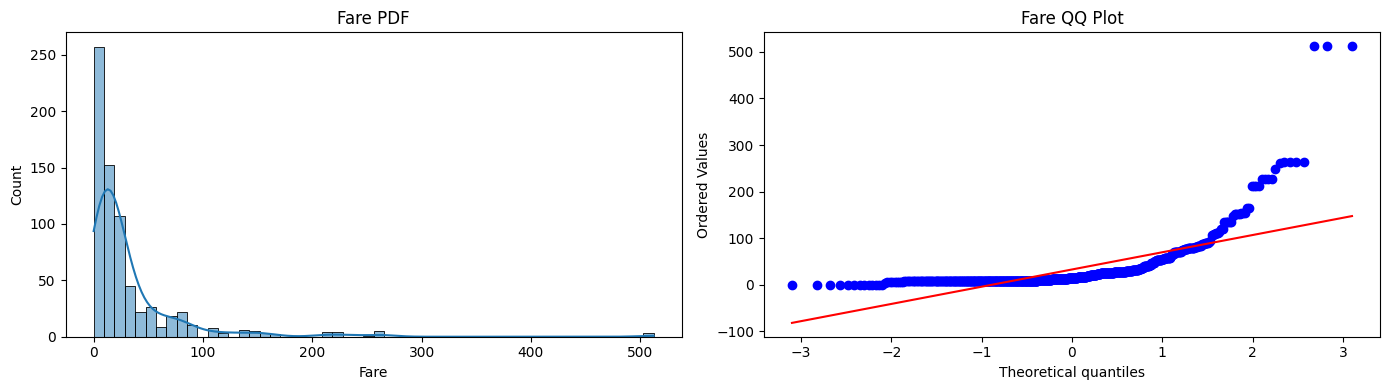

In [21]:
plt.close('all')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))


sns.histplot(X_train['Fare'], kde=True, ax=ax[0])
ax[0].set_title('Fare PDF')

stats.probplot(X_train['Fare'], dist='norm', plot=ax[1])
ax[1].set_title('Fare QQ Plot')

plt.tight_layout()
plt.show()

In [22]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [25]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred_lr = clf.predict(X_test)
y_pred_tree = clf2.predict(X_test)

print(f'Accuracy score of Logistic regression: {accuracy_score(y_pred_lr, y_test)}')
print(f'Accuracy score of Decision Tree: {accuracy_score(y_pred_tree, y_test)}')

Accuracy score of Logistic regression: 0.6480446927374302
Accuracy score of Decision Tree: 0.659217877094972


In [26]:
trf = FunctionTransformer(func=np.log1p)

In [27]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [28]:
clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred_lr = clf.predict(X_test_transformed)
y_pred_tree = clf2.predict(X_test_transformed)

print('After Function Transformation:')
print(f'Accuracy score of LR: {accuracy_score(y_pred_lr, y_test)}')
print(f'Accuracy score of DT: {accuracy_score(y_pred_tree, y_test)}')

After Function Transformation:
Accuracy score of LR: 0.6815642458100558
Accuracy score of DT: 0.6703910614525139


In [29]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print('DT', np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6678277153558053


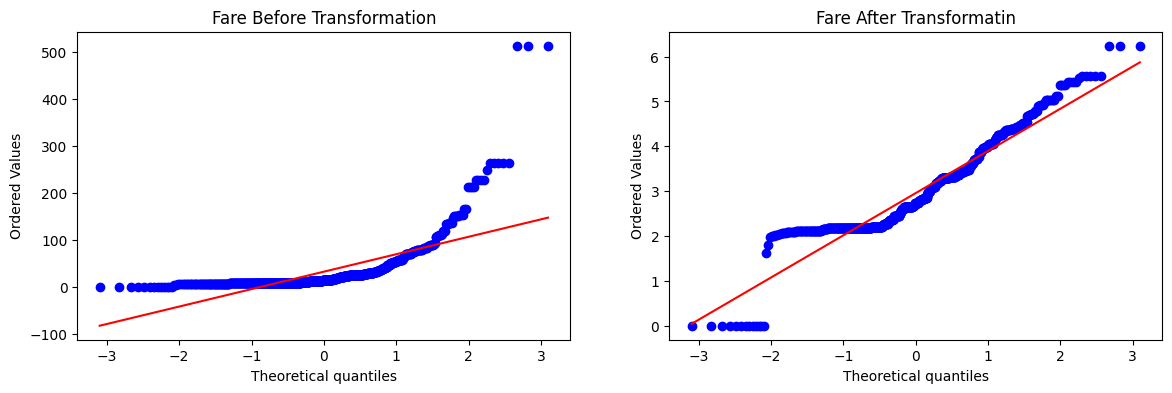

In [30]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Before Transformation')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist='norm', plot=plt)
plt.title('Fare After Transformatin')
plt.show()

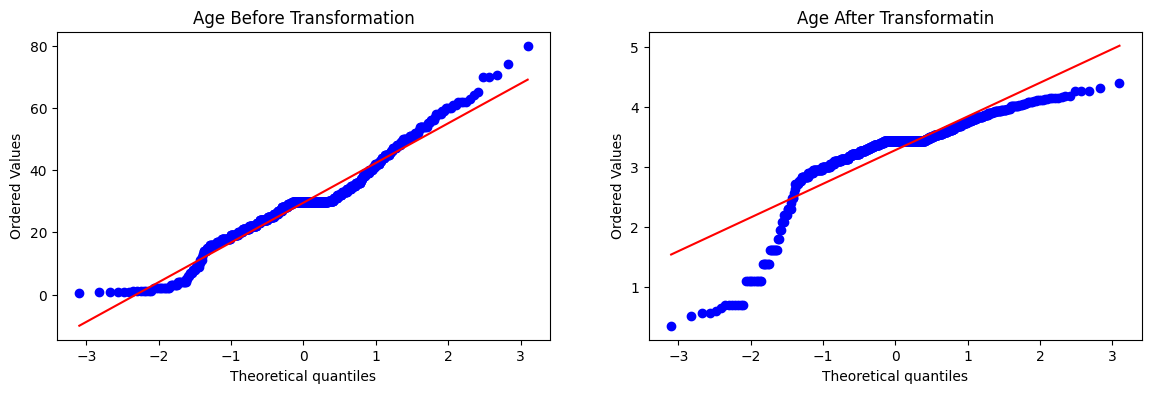

In [31]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age Before Transformation')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist='norm', plot=plt)
plt.title('Age After Transformatin')
plt.show()

In [32]:
trf2 = ColumnTransformer([
    ('log', FunctionTransformer(func=np.log1p), ['Fare']),
], remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [33]:
clf = LogisticRegression()
clf_tree = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf_tree.fit(X_train_transformed2, y_train)

y_pred_lr = clf.predict(X_test_transformed2)
y_pred_tree = clf.predict(X_test_transformed2)

print(f'Accuracy LR: {accuracy_score(y_pred_lr, y_test)}')
print(f'Accuracy DT: {accuracy_score(y_pred_tree, y_test)}')

Accuracy LR: 0.6703910614525139
Accuracy DT: 0.6703910614525139


In [34]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf_tree = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print('DT', np.mean(cross_val_score(clf_tree, X_transformed2, y, scoring='accuracy', cv=10)))

LR 0.6712609238451936
DT 0.6577028714107366


In [35]:
def  apply_transform(transform):
    X = df.iloc[:,1:3]
    X['Fare'] = X['Fare'].replace(0, 1e-10)
    y = df.iloc[:, 0]
    
    trf = ColumnTransformer([
        (f'{transform}', FunctionTransformer(transform), ['Fare'])
    ], remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print('Accuracy LR:', np.mean(cross_val_score(clf, X_trans, y, cv=10, scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    
    plt.subplot(121)
    stats.probplot(X['Fare'], dist='norm', plot=plt)
    plt.title('Fare Before Transformation')
    
    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist='norm', plot=plt)
    plt.title('Fare After Transformation')
    plt.show()

Accuracy LR: 0.6589013732833957


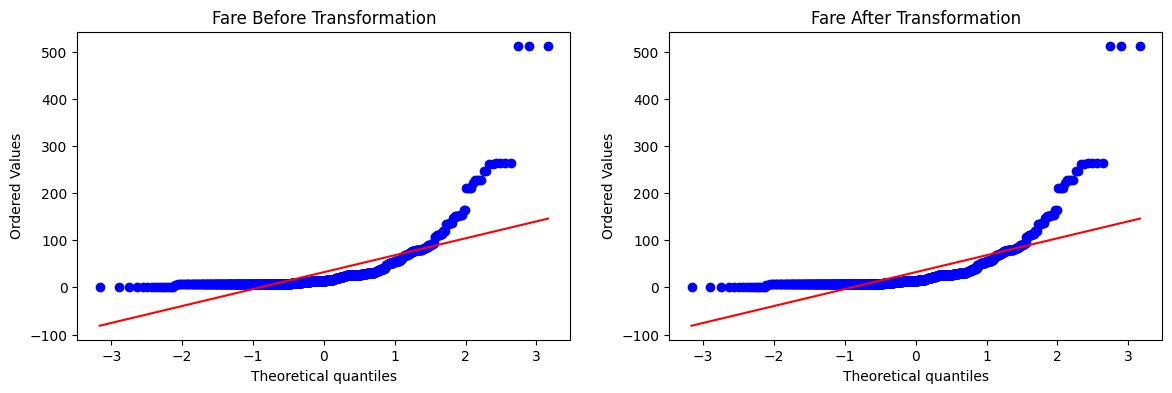

In [38]:
apply_transform(lambda x: x)

Accuracy LR: 0.6589013732833957


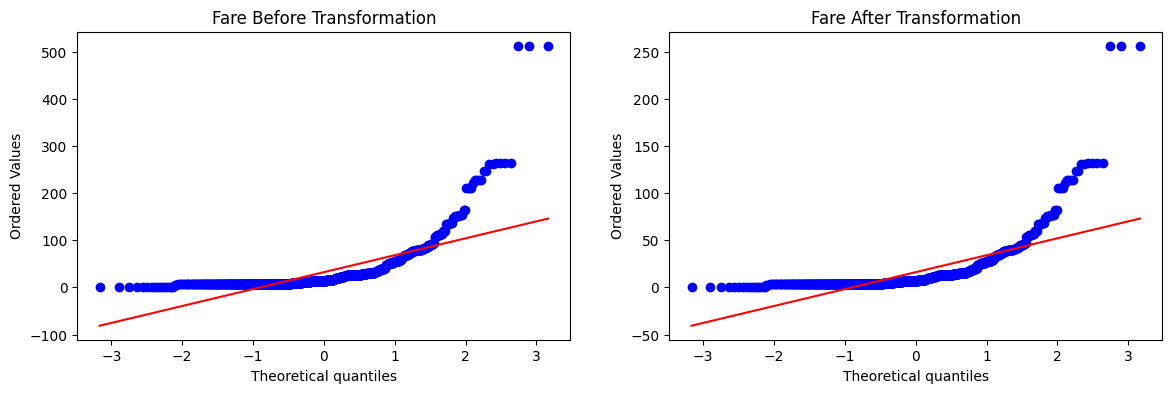

In [41]:
apply_transform(lambda x:x**1/2)

Accuracy LR: 0.61729088639201


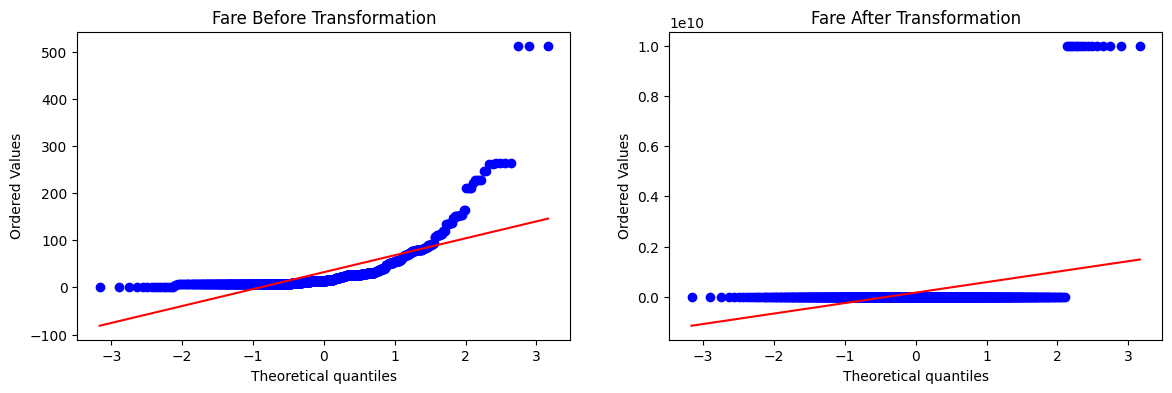

In [42]:
apply_transform(lambda x : np.reciprocal(x) )

Accuracy LR: 0.6712609238451936


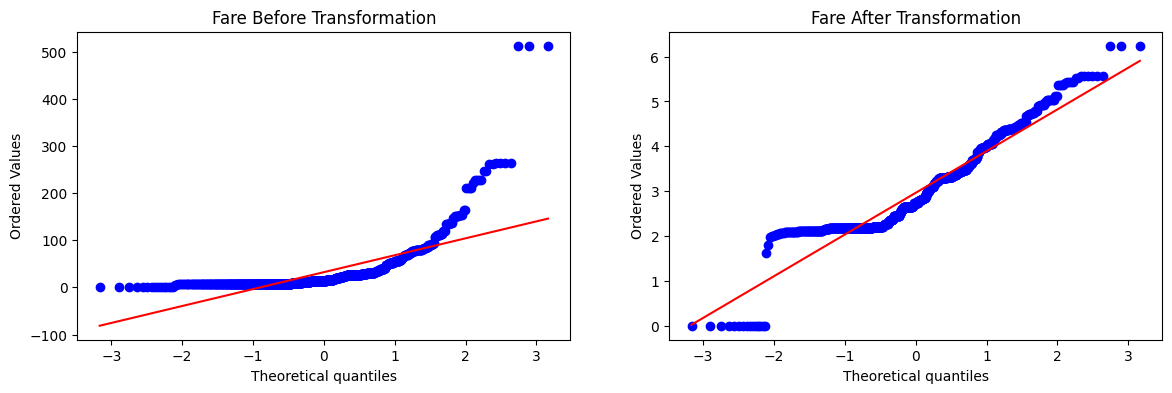

In [43]:
# Log Transformation
apply_transform(lambda x : np.log1p(x))